<a href="https://colab.research.google.com/github/Ayla-boss/Finance-analysis-/blob/main/Analysis_tasks_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas matplotlib openpyxl

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
df = pd.read_excel('finance_transactions_dataset.xlsx')
print(df.shape)
print(df.columns.tolist())

(1000, 14)
['Transaction_ID', 'Company', 'Sector', 'Department', 'Transaction_Type', 'Category', 'Amount', 'Tax_Rate', 'Tax_Amount', 'Net_Amount', 'Currency', 'Transaction_Date', 'Approval_Status', 'Analyst']


In [ ]:
df.head()        # first 5 rows
df.info()        # column types + missing values
df.describe()    # statistics
df.isnull().sum() # missing values count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1000 non-null   object 
 1   Company           956 non-null    object 
 2   Sector            1000 non-null   object 
 3   Department        946 non-null    object 
 4   Transaction_Type  1000 non-null   object 
 5   Category          211 non-null    object 
 6   Amount            961 non-null    float64
 7   Tax_Rate          1000 non-null   float64
 8   Tax_Amount        1000 non-null   float64
 9   Net_Amount        960 non-null    float64
 10  Currency          1000 non-null   object 
 11  Transaction_Date  952 non-null    object 
 12  Approval_Status   961 non-null    object 
 13  Analyst           955 non-null    object 
dtypes: float64(4), object(10)
memory usage: 109.5+ KB


,0
Transaction_ID,0
Company,44
Sector,0
Department,54
Transaction_Type,0
Category,789
Amount,39
Tax_Rate,0
Tax_Amount,0
Net_Amount,40


In [ ]:
df.dropna(subset=['Amount','Net_Amount','Transaction_Date','Approval_Status'], inplace=True)

In [ ]:
df['Company'] = df['Company'].fillna('Unknown')
df['Category'] = df['Category'].fillna('N/A')

In [ ]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str)

In [ ]:
df.drop_duplicates(inplace=True)

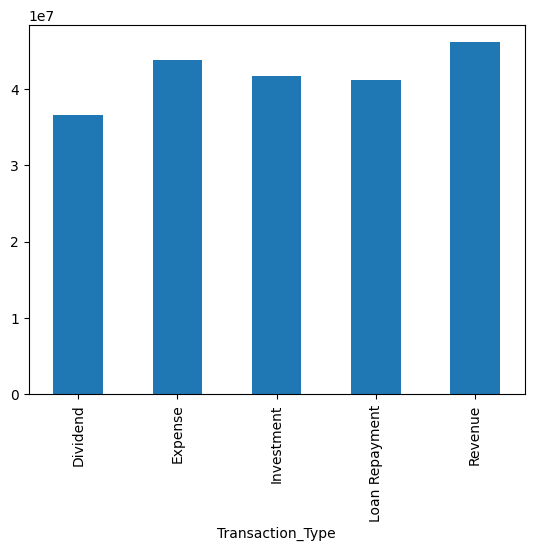

In [ ]:
df.groupby('Transaction_Type')['Amount'].sum().plot(kind='bar')
plt.show()

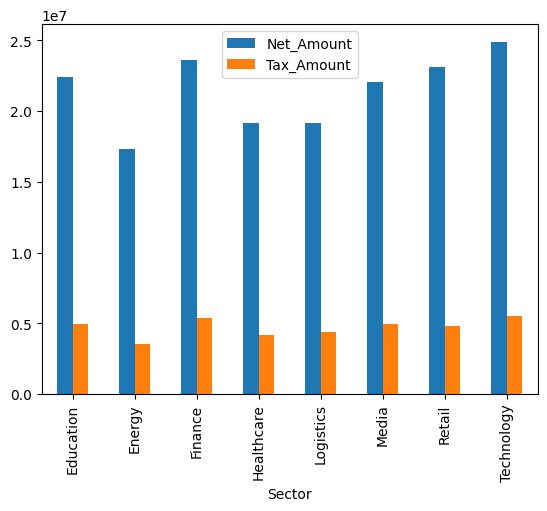

In [ ]:
df.groupby('Sector')[['Net_Amount','Tax_Amount']].sum().plot(kind='bar')
plt.show()

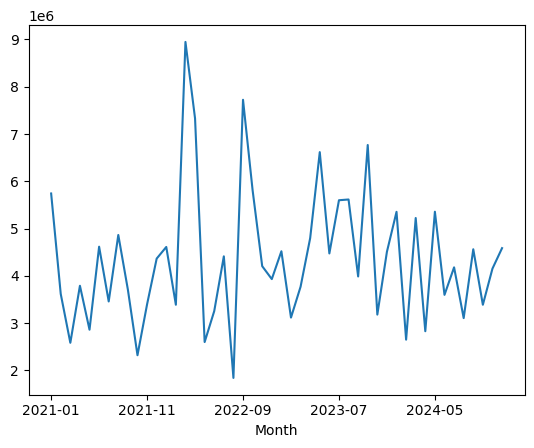

In [ ]:
df.groupby('Month')['Amount'].sum().plot(kind='line')
plt.show()

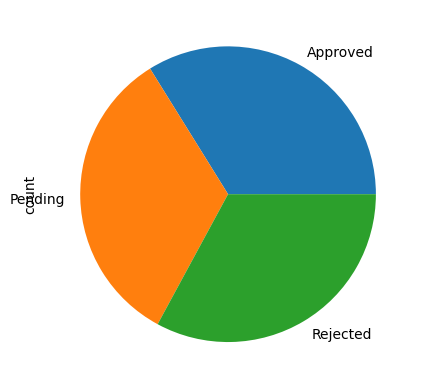

In [ ]:
df['Approval_Status'].value_counts().plot(kind='pie')
plt.show()

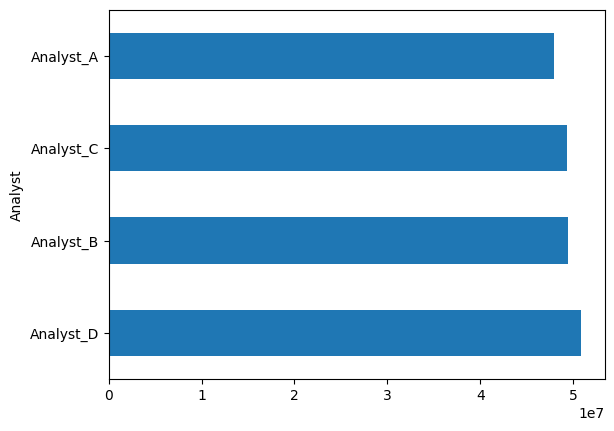

In [ ]:
df.groupby('Analyst')['Amount'].sum().nlargest(5).plot(kind='barh')
plt.show()

In [ ]:
print(f"Total Amount: ${df['Amount'].sum():,.0f}")
print(f"Top Sector: {df.groupby('Sector')['Amount'].sum().idxmax()}")

Total Amount: $209,284,457
Top Sector: Technology
